# Dependencies and Data

In [1]:
# Dependencies
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [2]:
# Load Data
path = "C:\\Users\\sonla\\Documents\\EnergyPrices\\Data\\train.csv"
data = pd.read_csv(path)
data.head()

,Date_Begin_Local,ACTUAL_POOL_PRICE,ACTUAL_AIL,T2M_CALGARY,WS50M_CALGARY,T2M_LETHBRIDGE,WS50M_LETHBRIDGE,T2M_AVG,WS50M_AVG,RH2M_AVG,...,wind_power_proxy,is_solar_generating,is_chinook,delta_price,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos
0,2020-01-08 00:00:00,27.25,9869.0,-6.90,6.48,-0.18,9.41,-6.500000,9.153333,95.103333,...,766.898405,0,0,0.10,0.000000,1.000000,0.974928,-0.222521,0.5,0.866025
1,2020-01-08 01:00:00,26.63,9728.0,-5.95,7.18,-0.57,9.47,-6.256667,9.803333,95.253333,...,942.152727,0,0,-0.62,0.258819,0.965926,0.974928,-0.222521,0.5,0.866025
2,2020-01-08 02:00:00,25.41,9676.0,-5.29,7.42,-1.04,9.56,-6.096667,9.913333,95.220000,...,974.224682,0,0,-1.22,0.500000,0.866025,0.974928,-0.222521,0.5,0.866025
3,2020-01-08 03:00:00,26.93,9727.0,-5.43,7.36,-1.21,9.76,-6.336667,9.323333,95.933333,...,810.426503,0,0,1.52,0.707107,0.707107,0.974928,-0.222521,0.5,0.866025
4,2020-01-08 04:00:00,28.02,9808.0,-6.02,7.36,-0.89,10.85,-6.606667,9.123333,95.936667,...,759.382576,0,0,1.09,0.866025,0.500000,0.974928,-0.222521,0.5,0.866025


In [3]:
data.columns

Index(['Date_Begin_Local', 'ACTUAL_POOL_PRICE', 'ACTUAL_AIL', 'T2M_CALGARY',
       'WS50M_CALGARY', 'T2M_LETHBRIDGE', 'WS50M_LETHBRIDGE', 'T2M_AVG',
       'WS50M_AVG', 'RH2M_AVG', 'GHI_AVG', 'price_lag_1', 'price_lag_24',
       'price_lag_168', 'AIL_lag_1', 'AIL_lag_24', 'T2M_AVG_lag_24',
       'WS50M_AVG_lag_1', 'price_rolling_std_24', 'is_heating_season',
       'is_cooling_season', 'is_cold_snap', 'is_temp_dropping_fast',
       'is_low_wind', 'wind_power_proxy', 'is_solar_generating', 'is_chinook',
       'delta_price', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos',
       'month_sin', 'month_cos'],
      dtype='object')

# Prepare Dataset for training

In [11]:
# Drop Unnecessary Columns
data = data.drop(columns=["Date_Begin_Local"])

# Extract target variable
X = data.drop(columns=["delta_price"])
y = data["delta_price"]

# Train-Validation Split
split =0.8
split_index = int(len(X) * split)
X_train, X_val = X[:split_index], X[split_index:]
y_train, y_val = y[:split_index], y[split_index:]

# Train LSTM Model

## 1. Helper classes and functions

In [12]:
# Time series loader
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y, lookback):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.float32)
        self.lookback = lookback

    def __len__(self):
        return len(self.X) - self.lookback

    def __getitem__(self, idx):
        X_seq = self.X[idx : idx + self.lookback]
        y_seq = self.y[idx + self.lookback]
        return X_seq, y_seq
    
# LSTM Model
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        super(LSTMModel, self).__init__()

        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        lstm_out = lstm_out[:, -1, :]
        lstm_out = self.dropout(lstm_out)
        lstm_out = self.fc(lstm_out)
        return lstm_out.squeeze(-1)
    
class EarlyStopping:
    def __init__(self, patience, min_delta):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = float('inf')
        self.best_state = None

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss  = val_loss
            self.counter    = 0
            self.best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            self.counter += 1

        return self.counter >= self.patience
    
# Feature Scaling
scaler = StandardScaler()


## 2. Model SETUP

In [5]:
# Scale features
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Hyperparameters
LOOKBACK = 48
BATCHSIZE = 32
INPUT_SIZE = X_train_scaled.shape[1]
HIDDEN_SIZE = 32
NUM_LAYERS = 2
DROPOUT = 0.45
LEARNING_RATE = 0.00467

# Create datasets
train_dataset = TimeSeriesDataset(X_train_scaled, y_train, LOOKBACK)
val_dataset = TimeSeriesDataset(X_val_scaled, y_val, LOOKBACK)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCHSIZE, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=BATCHSIZE, shuffle=False)

# Initialize model, loss function, and optimizer
model = LSTMModel(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, DROPOUT)
loss_function = nn.HuberLoss(delta=10.0)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

# SETUP Logs:
print(f"Train sequences : {len(train_dataset)}")
print(f"Validation sequences : {len(val_dataset)}")
print(f"Sequence shape  : ({LOOKBACK}, {X_train_scaled.shape[1]})")
print(model)
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Train sequences : 31159
Validation sequences : 7754
Sequence shape  : (48, 25)
LSTMModel(
  (lstm): LSTM(25, 32, num_layers=2, batch_first=True, dropout=0.45)
  (dropout): Dropout(p=0.45, inplace=False)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)
Trainable params: 16,033


## 3. LSTM Training

In [6]:
train_losses = []
val_losses = []
EPOCHS = 150

early_stopping = EarlyStopping(patience=15, min_delta=0)

for epoch in range(EPOCHS):
    # Training Pass -----
    model.train()
    epoch_train_loss = 0
    for X_batch, y_batch in train_loader:
        # Reset gradients
        optimizer.zero_grad()
        # Forward pass
        fw_pass_outputs = model(X_batch)
        # Compute loss
        loss = loss_function(fw_pass_outputs, y_batch)
        # Backward pass
        loss.backward()
        # Gradient clipping (Keep gradients in check)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        # Update weights
        optimizer.step()
        # Accumulate loss
        epoch_train_loss += loss.item() * X_batch.size(0)

    epoch_train_loss /= len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    # Validation Pass -----
    model.eval()
    epoch_val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            val_pass_outputs = model(X_batch)
            loss = loss_function(val_pass_outputs, y_batch)
            epoch_val_loss += loss.item() * X_batch.size(0)

    epoch_val_loss /= len(val_loader.dataset)
    val_losses.append(epoch_val_loss)

    scheduler.step(epoch_val_loss)

    if early_stopping(epoch_val_loss, model):
        print(f"Early stopping at epoch {epoch+1}")
        break

    print(f"Epoch {epoch+1}/{EPOCHS} - Train Loss: {epoch_train_loss:.4f} - Val Loss: {epoch_val_loss:.4f}")

if early_stopping.best_state is not None:
    model.load_state_dict(early_stopping.best_state)
    print(f"Best val loss: {early_stopping.best_loss:.4f}")
else:
    print("Warning: no best state saved.")

Epoch 1/150 - Train Loss: 305.0187 - Val Loss: 273.2734
Epoch 2/150 - Train Loss: 301.9925 - Val Loss: 269.1071
Epoch 3/150 - Train Loss: 299.8089 - Val Loss: 267.1072
Epoch 4/150 - Train Loss: 297.9469 - Val Loss: 265.8502
Epoch 5/150 - Train Loss: 297.0656 - Val Loss: 264.4303
Epoch 6/150 - Train Loss: 295.2959 - Val Loss: 262.2296
Epoch 7/150 - Train Loss: 294.5067 - Val Loss: 261.8123
Epoch 8/150 - Train Loss: 293.2441 - Val Loss: 260.9996
Epoch 9/150 - Train Loss: 292.7180 - Val Loss: 260.1996
Epoch 10/150 - Train Loss: 291.8253 - Val Loss: 259.3750
Epoch 11/150 - Train Loss: 290.8665 - Val Loss: 260.1003
Epoch 12/150 - Train Loss: 289.6279 - Val Loss: 259.4562
Epoch 13/150 - Train Loss: 289.5353 - Val Loss: 259.4486
Epoch 14/150 - Train Loss: 289.7542 - Val Loss: 259.7910
Epoch 15/150 - Train Loss: 288.9871 - Val Loss: 259.3353
Epoch 16/150 - Train Loss: 288.5328 - Val Loss: 260.8863
Epoch 17/150 - Train Loss: 289.4280 - Val Loss: 260.4617
Epoch 18/150 - Train Loss: 289.0454 - Va

In [ ]:
## ── Ablation Test ────────────────────────────────────────────────────────────
## Run ONCE after training to identify which features earn their place.
## Uses fixed Optuna hyperparameters — we are testing features, not tuning.
## Each trial drops one candidate feature and reports the change in val RMSE.
## Only the final summary table is printed — copy and paste that block.
##
## Candidates tested (sparse flags + new features):
##   is_chinook, is_temp_dropping_fast, is_cold_snap, is_cooling_season,
##   is_low_wind, is_solar_generating, wind_power_proxy, price_rolling_std_24,
##   RH2M_AVG
##
## Decision rule:
##   KEEP    -> dropping made RMSE worse by >0.5 $/MWh — feature earns its place
##   DROP    -> removing improved RMSE by >0.5 $/MWh — feature adds noise
##   NEUTRAL -> within +/-0.5 $/MWh — marginal, remove to simplify
## ─────────────────────────────────────────────────────────────────────────────
#import time
#from sklearn.metrics import mean_squared_error, mean_absolute_error
#from sklearn.preprocessing import StandardScaler
#import torch
#import torch.nn as nn
#from torch.utils.data import DataLoader
#
## ── Fixed settings (Optuna-selected) ─────────────────────────────────────────
#_LOOKBACK    = 48
#_BATCHSIZE   = 32
#_NUM_LAYERS  = 2
#_HIDDEN      = 32
#_DROPOUT     = 0.2
#_LR          = 0.0001
#_MAX_EPOCHS  = 60   # enough to converge; short enough to finish in ~2-3 hrs
#_ES_PATIENCE = 15
#
## ── Features to test dropping (one at a time) ────────────────────────────────
#ABLATION_CANDIDATES = [
#    "is_chinook",
#    "is_temp_dropping_fast",
#    "is_cold_snap",
#    "is_cooling_season",
#    "is_low_wind",
#    "is_solar_generating",
#    "wind_power_proxy",
#    "price_rolling_std_24",
#    "RH2M_AVG",
#]
#
## ── Helper: train one trial, return best val RMSE + MAE ──────────────────────
#def run_trial(X_tr, X_vl, y_tr, y_vl):
#    _scaler = StandardScaler()
#    Xtr_s   = _scaler.fit_transform(X_tr)
#    Xvl_s   = _scaler.transform(X_vl)
#
#    tr_ds  = TimeSeriesDataset(Xtr_s, y_tr, _LOOKBACK)
#    vl_ds  = TimeSeriesDataset(Xvl_s, y_vl, _LOOKBACK)
#    tr_ldr = DataLoader(tr_ds, batch_size=_BATCHSIZE, shuffle=False)
#    vl_ldr = DataLoader(vl_ds, batch_size=_BATCHSIZE, shuffle=False)
#
#    _model     = LSTMModel(Xtr_s.shape[1], _HIDDEN, _NUM_LAYERS, _DROPOUT)
#    _loss_fn   = nn.HuberLoss(delta=10.0)
#    _optim     = torch.optim.Adam(_model.parameters(), lr=_LR)
#    _sched     = torch.optim.lr_scheduler.ReduceLROnPlateau(
#                     _optim, mode='min', factor=0.5, patience=5)
#    _es        = EarlyStopping(patience=_ES_PATIENCE, min_delta=0)
#
#    for epoch in range(_MAX_EPOCHS):
#        _model.train()
#        for Xb, yb in tr_ldr:
#            _optim.zero_grad()
#            loss = _loss_fn(_model(Xb), yb)
#            loss.backward()
#            nn.utils.clip_grad_norm_(_model.parameters(), max_norm=1.0)
#            _optim.step()
#
#        _model.eval()
#        vl_loss = 0
#        with torch.no_grad():
#            for Xb, yb in vl_ldr:
#                vl_loss += _loss_fn(_model(Xb), yb).item() * Xb.size(0)
#        vl_loss /= len(vl_ldr.dataset)
#        _sched.step(vl_loss)
#        if _es(vl_loss, _model):
#            break
#
#    if _es.best_state:
#        _model.load_state_dict(_es.best_state)
#    _model.eval()
#    preds, targets = [], []
#    with torch.no_grad():
#        for Xb, yb in vl_ldr:
#            preds.extend(_model(Xb).numpy())
#            targets.extend(yb.numpy())
#    rmse = mean_squared_error(targets, preds) ** 0.5
#    mae  = mean_absolute_error(targets, preds)
#    return rmse, mae
#
## ── Run ablation ──────────────────────────────────────────────────────────────
#n_trials = len(ABLATION_CANDIDATES) + 1
#print(f"Running ablation: {n_trials} trials x up to {_MAX_EPOCHS} epochs each")
#print(f"Fixed: hidden={_HIDDEN}, dropout={_DROPOUT}, lr={_LR}")
#print("-" * 60)
#
#results      = []
#total_start  = time.time()
#
## Baseline — all features
#t0 = time.time()
#base_rmse, base_mae = run_trial(X_train, X_val, y_train, y_val)
#results.append(("BASELINE (all features)", base_rmse, base_mae, time.time() - t0))
#print(f"[1/{n_trials}] BASELINE  RMSE={base_rmse:.4f}  ({results[-1][-1]/60:.1f} min)")
#
## One-feature-out trials
#for i, feat in enumerate(ABLATION_CANDIDATES, start=2):
#    if feat not in X_train.columns:
#        print(f"[{i}/{n_trials}] SKIP {feat} — not in feature set")
#        continue
#    t0 = time.time()
#    rmse, mae = run_trial(
#        X_train.drop(columns=[feat]),
#        X_val.drop(columns=[feat]),
#        y_train, y_val
#    )
#    elapsed = time.time() - t0
#    delta   = rmse - base_rmse
#    tag     = "WORSE" if delta > 0.5 else ("BETTER" if delta < -0.5 else "~same")
#    results.append((f"drop {feat}", rmse, mae, elapsed))
#    print(f"[{i}/{n_trials}] drop {feat:<28} RMSE={rmse:.4f}  delta={delta:+.4f}  {tag}  ({elapsed/60:.1f} min)")
#
#total_min = (time.time() - total_start) / 60
#
## ── Final summary table — copy this block ────────────────────────────────────
#print()
#print("=" * 72)
#print("  ABLATION SUMMARY — copy this block")
#print("=" * 72)
#print(f"  {'Trial':<32} {'Val RMSE':>9} {'Delta':>9} {'Val MAE':>9} {'Action':>9}")
#print(f"  {'-'*32} {'-'*9} {'-'*9} {'-'*9} {'-'*9}")
#for name, rmse, mae, _ in results:
#    delta = rmse - base_rmse
#    if name.startswith("BASELINE"):
#        action, delta_str = "—", "—"
#    elif delta > 0.5:
#        action, delta_str = "KEEP", f"{delta:+.4f}"
#    elif delta < -0.5:
#        action, delta_str = "DROP", f"{delta:+.4f}"
#    else:
#        action, delta_str = "NEUTRAL", f"{delta:+.4f}"
#    print(f"  {name:<32} {rmse:>9.4f} {delta_str:>9} {mae:>9.4f} {action:>9}")
#print("=" * 72)
#print(f"  Total time: {total_min:.1f} min")
#print("=" * 72)
#print()
#print("  KEEP    -> feature removal hurt RMSE >0.5 $/MWh — keep it")
#print("  DROP    -> feature removal improved RMSE >0.5 $/MWh — remove from pipeline")
#print("  NEUTRAL -> within +/-0.5 $/MWh — marginal, consider dropping for simplicity")


Running ablation: 10 trials x up to 60 epochs each
Fixed: hidden=32, dropout=0.2, lr=0.0001
------------------------------------------------------------
[1/10] BASELINE  RMSE=69.4265  (7.8 min)
[2/10] drop is_chinook                   RMSE=69.2277  delta=-0.1988  ~same  (7.8 min)
[3/10] drop is_temp_dropping_fast        RMSE=68.9358  delta=-0.4907  ~same  (7.7 min)
[4/10] drop is_cold_snap                 RMSE=69.5220  delta=+0.0955  ~same  (7.7 min)
[5/10] drop is_cooling_season            RMSE=69.4494  delta=+0.0229  ~same  (7.7 min)
[6/10] drop is_low_wind                  RMSE=69.0715  delta=-0.3549  ~same  (7.8 min)
[7/10] drop is_solar_generating          RMSE=69.2858  delta=-0.1407  ~same  (8.5 min)
[8/10] drop wind_power_proxy             RMSE=69.2430  delta=-0.1835  ~same  (8.3 min)
[9/10] drop price_rolling_std_24         RMSE=69.5331  delta=+0.1066  ~same  (8.7 min)
[10/10] drop RH2M_AVG                     RMSE=69.5746  delta=+0.1482  ~same  (8.7 min)

  ABLATION SUMMARY — 

In [ ]:
#========================================================================
#  ABLATION SUMMARY — copy this block
#========================================================================
#  Trial                             Val RMSE     Delta   Val MAE    Action
#  -------------------------------- --------- --------- --------- ---------
#  BASELINE (all features)            69.4265         —   29.8201         —
#  drop is_chinook                    69.2277   -0.1988   29.6895   NEUTRAL
#  drop is_temp_dropping_fast         68.9358   -0.4907   29.5765   NEUTRAL
#  drop is_cold_snap                  69.5220   +0.0955   29.8603   NEUTRAL
#  drop is_cooling_season             69.4494   +0.0229   29.7642   NEUTRAL
#  drop is_low_wind                   69.0715   -0.3549   29.5304   NEUTRAL
#  drop is_solar_generating           69.2858   -0.1407   29.7367   NEUTRAL
#  drop wind_power_proxy              69.2430   -0.1835   29.6452   NEUTRAL
#  drop price_rolling_std_24          69.5331   +0.1066   29.7449   NEUTRAL
#  drop RH2M_AVG                      69.5746   +0.1482   29.8214   NEUTRAL
#========================================================================
#  Total time: 80.7 min
#========================================================================

In [ ]:
## ── Hyperparameter Tuning with Optuna ───────────────────────────────────────
## Run this cell ONCE to find optimal hyperparameters, then comment it out.
## Searches: hidden_size, dropout, learning_rate  |  Fixed: num_layers=2, lookback=48
## Budget: ~2-3 hours on CPU (timeout=9000s, up to 25 trials)
## ─────────────────────────────────────────────────────────────────────────────
#import optuna
#import time
#import torch
#import torch.nn as nn
#from sklearn.preprocessing import StandardScaler
#from torch.utils.data import DataLoader
#optuna.logging.set_verbosity(optuna.logging.WARNING)
#
## ── Fixed during search ───────────────────────────────────────────────────────
#_LOOKBACK    = 48
#_BATCHSIZE   = 32
#_NUM_LAYERS  = 2
#_MAX_EPOCHS  = 60   # per trial — enough to see convergence, short enough for budget
#_ES_PATIENCE = 8    # aggressive early stopping per trial to kill bad configs fast
#
## ── Pre-build loaders once — reused by every trial ───────────────────────────
#_scaler = StandardScaler()
#_X_train_s = _scaler.fit_transform(X_train)
#_X_val_s   = _scaler.transform(X_val)
#
#_train_ds  = TimeSeriesDataset(_X_train_s, y_train, _LOOKBACK)
#_val_ds    = TimeSeriesDataset(_X_val_s,   y_val,   _LOOKBACK)
#_train_ldr = DataLoader(_train_ds, batch_size=_BATCHSIZE, shuffle=False)
#_val_ldr   = DataLoader(_val_ds,   batch_size=_BATCHSIZE, shuffle=False)
#
#_INPUT_SIZE = _X_train_s.shape[1]   # 25
#
#def objective(trial):
#    # ── Search space ─────────────────────────────────────────────────────────
#    # hidden_size: 3 candidates — small/medium/large for a ~31k sequence dataset
#    # dropout:     0.1–0.5 in 0.05 steps — wide enough to catch under/over-regularisation
#    # lr:          log-uniform 1e-4 to 5e-3 — Adam sweet spot for LSTMs
#    hidden_size = trial.suggest_categorical("hidden_size", [32, 64, 128])
#    dropout     = trial.suggest_float("dropout", 0.1, 0.5, step=0.05)
#    lr          = trial.suggest_float("lr", 1e-4, 5e-3, log=True)
#
#    model          = LSTMModel(_INPUT_SIZE, hidden_size, _NUM_LAYERS, dropout)
#    loss_fn        = nn.HuberLoss(delta=10.0)
#    optimizer      = torch.optim.Adam(model.parameters(), lr=lr)
#    scheduler      = torch.optim.lr_scheduler.ReduceLROnPlateau(
#                         optimizer, mode="min", factor=0.5, patience=5)
#    early_stopping = EarlyStopping(patience=_ES_PATIENCE, min_delta=0)
#
#    for epoch in range(_MAX_EPOCHS):
#        # Training pass
#        model.train()
#        for X_batch, y_batch in _train_ldr:
#            optimizer.zero_grad()
#            loss = loss_fn(model(X_batch), y_batch)
#            loss.backward()
#            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
#            optimizer.step()
#
#        # Validation pass
#        model.eval()
#        epoch_val_loss = 0
#        with torch.no_grad():
#            for X_batch, y_batch in _val_ldr:
#                epoch_val_loss += loss_fn(model(X_batch), y_batch).item() * X_batch.size(0)
#        epoch_val_loss /= len(_val_ldr.dataset)
#
#        scheduler.step(epoch_val_loss)
#
#        # Optuna pruning — kill clearly bad trials after epoch 5
#        trial.report(epoch_val_loss, epoch)
#        if trial.should_prune():
#            raise optuna.exceptions.TrialPruned()
#
#        if early_stopping(epoch_val_loss, model):
#            break
#
#    return early_stopping.best_loss
#
## ── Run the study ─────────────────────────────────────────────────────────────
## TPESampler: Bayesian search — smarter than random after the first few trials
## MedianPruner: prune a trial if its val loss is worse than the median at that epoch
#study = optuna.create_study(
#    direction="minimize",
#    sampler=optuna.samplers.TPESampler(seed=42),
#    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=5)
#)
#
#print("Starting Optuna search — budget: 2.5 hrs / 25 trials")
#print(f"Search space: hidden_size=[32,64,128]  dropout=[0.10-0.50]  lr=[1e-4, 5e-3]")
#print("-" * 60)
#
#start = time.time()
#study.optimize(
#    objective,
#    n_trials=25,
#    timeout=18000,          # hard stop at 2.5 hours regardless of trial count
#    show_progress_bar=True
#)
#
#elapsed = (time.time() - start) / 60
#completed = len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])
#pruned    = len([t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED])
#
#print("" + "=" * 60)
#print("  Optuna Search Complete")
#print("=" * 60)
#print(f"  Elapsed     : {elapsed:.1f} min")
#print(f"  Trials done : {len(study.trials)}  (completed={completed}, pruned={pruned})")
#print(f"  Best val loss: {study.best_value:.4f}")
#print("=" * 60)
#print("  BEST HYPERPARAMETERS")
#print("=" * 60)
#for k, v in study.best_params.items():
#    print(f"  {k:<15}: {v}")
#print("=" * 60)
# ==============================================================
# Best params:
# hidden_size: 32
# dropout: 0.45
# lr: 0.00467



## 4. Model Validation Eval

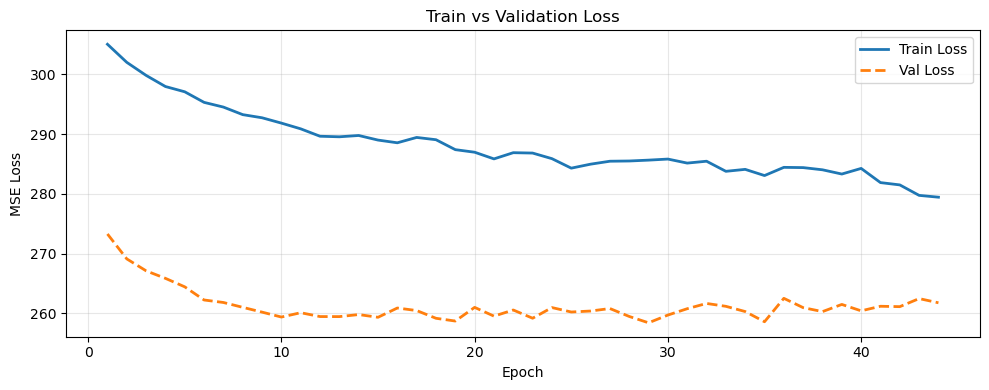

   Validation Metrics
  MSE:    258.4136 $/MWh²
  RMSE:    66.7905 $/MWh
  MAE:     29.2951 $/MWh
   Naive Baseline Metrics
Naive MAE:  31.2402 $/MWh
Naive RMSE: 73.0483 $/MWh


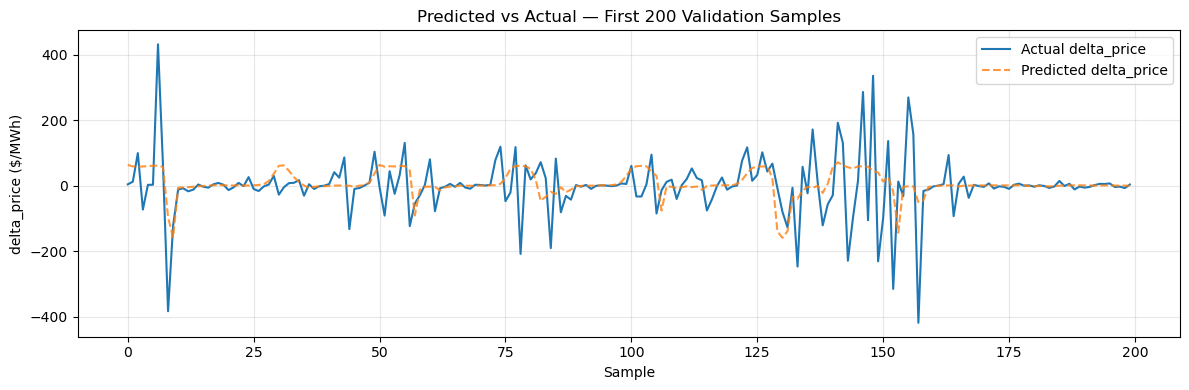

In [8]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

# ── 1. Train vs Val Loss Curve ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
epochs_ran = range(1, len(train_losses) + 1)

ax.plot(epochs_ran, train_losses, label="Train Loss", linewidth=2)
ax.plot(epochs_ran, val_losses,   label="Val Loss",   linewidth=2, linestyle="--")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.set_title("Train vs Validation Loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── 2. Collect predictions on validation set ─────────────────────────────
model.eval()
all_preds   = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        preds = model(X_batch)
        all_preds.extend(preds.numpy())
        all_targets.extend(y_batch.numpy())

all_preds   = np.array(all_preds)
all_targets = np.array(all_targets)

# ── 3. RMSE ──────────────────────────────────────────────────────────────
rmse = mean_squared_error(all_targets, all_preds) ** 0.5
mae = mean_absolute_error(all_targets, all_preds)

# ── 4. Print metrics ─────────────────────────────────────────────────────
print("=" * 40)
print("   Validation Metrics")
print("=" * 40)
print(f"  MSE:  {early_stopping.best_loss:>10.4f} $/MWh²")
print(f"  RMSE: {rmse:>10.4f} $/MWh")
print(f"  MAE:  {mae:>10.4f} $/MWh")
print("=" * 40)
# Naive baseline: delta_price = 0 (predict no change)
naive_mae  = np.mean(np.abs(all_targets))
naive_rmse = np.std(all_targets)
print("=" * 40)
print("   Naive Baseline Metrics")
print("=" * 40)
print(f"Naive MAE:  {naive_mae:.4f} $/MWh")
print(f"Naive RMSE: {naive_rmse:.4f} $/MWh")
print("=" * 40)
# ── 5. Predicted vs Actual plot (first 200 samples) ─────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(all_targets[:200], label="Actual delta_price",    linewidth=1.5)
ax.plot(all_preds[:200],   label="Predicted delta_price", linewidth=1.5, linestyle="--", alpha=0.8)
ax.set_xlabel("Sample")
ax.set_ylabel("delta_price ($/MWh)")
ax.set_title("Predicted vs Actual — First 200 Validation Samples")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()